# **Lab Assignment 01: Probability Distributions and Data Visualization**
**Course:** Yesha Pandya

**Enrolment Number:** 23BT04175

**Div:** A **Batch:** C

**Aim:**
* Generate different probability distributions using NumPy
* Compare them with real-world distributions using the Seaborn Penguins dataset
* Visualize the results using Matplotlib histograms.

**Objectives:**
1. Understand synthetic random data generation techniques in AI.
2. Analyze and differentiate between Normal, Uniform, and Binomial distributions.
3. Master data visualization techniques using statistical histograms.

In [1]:
# Import core scientific computing and visualization libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure global plotting parameters for cleaner visualizations
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 0.8

## **1. Load + Explore the Real-World `penguins` Dataset**
we load the built-in `penguins` dataset to observe how these mathematical distributions appear in practice.

This dataset contains biological measurements of three penguin species from the Palmer Archipelago, Antarctica.

We drop rows containing missing values (`NaN`) to ensure numerical consistency during mathematical analysis.

In [2]:
# Load the integrated penguins dataset and remove missing entries
penguins_df = sns.load_dataset("penguins").dropna()

# Verify successful ingestion by evaluating dataframe dimensions
print("`Penguins` dataset injestion summary:\n")
print(f"Total rows (records) loaded: {penguins_df.shape[0]}")
print(f"Total columns (attributes) loaded: {penguins_df.shape[1]}")
print("\nFirst 5 instances of the real-world dataset:")

# Display a slice of the dataset to understand structural features and data types
penguins_df.head()

`Penguins` dataset injestion summary:

Total rows (records) loaded: 333
Total columns (attributes) loaded: 7

First 5 instances of the real-world dataset:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


## **2. Model the Normal (Gaussian) Distribution**
A Normal distribution is a continuous probability distribution symmetric about its mean $\implies$ showing that data points near the mean are more frequent in occurrence than data points far from the mean.

* **Synthetic Data Generation:** We use `np.random.normal()` to generate synthetic data modeled after the physical properties of penguins.
* **Real-World Comparison:** We extract the `flipper_length_mm` feature, which naturally models a Normal distribution due to biological variation.

In [10]:
# Extract real-world normal distribution values (Flipper Length)
real_normal = penguins_df['flipper_length_mm'].values

# Calculate exact empirical parameters to align our synthetic generation
normal_mean = np.mean(real_normal)
normal_std = np.std(real_normal)

# Generate synthetic normal distribution data utilizing calculated parameters
synthetic_normal = np.random.normal(loc=normal_mean, scale=normal_std, size=len(real_normal))

# Print verification metrics and display raw instances of the synthetic array
print("Normal distribution data metrics:\n")
print(f"Real Data Flipper Length Mean: {normal_mean:.2f} mm")
print(f"Real Data Flipper Length Std Dev: {normal_std:.2f} mm")
print(f"Generated Synthetic Array Shape: {synthetic_normal.shape}")
print(f"Synthetic Data Empirical Mean: {np.mean(synthetic_normal):.2f} mm")
print(f"Synthetic Data Empirical Std Dev: {np.std(synthetic_normal):.2f} mm")
print("\nFirst 15 instances of generated Synthetic Normal Data (Floating point array):")
print(synthetic_normal[:15])

Normal distribution data metrics:

Real Data Flipper Length Mean: 200.97 mm
Real Data Flipper Length Std Dev: 13.99 mm
Generated Synthetic Array Shape: (333,)
Synthetic Data Empirical Mean: 200.96 mm
Synthetic Data Empirical Std Dev: 14.23 mm

First 15 instances of generated Synthetic Normal Data (Floating point array):
[199.17836521 206.69613166 182.8786884  200.17855886 182.28104238
 195.01502579 211.24319455 186.60023229 185.51584683 222.57633053
 208.61555833 201.82059498 209.6270903  206.41160616 185.03889085]


### **Visualizing the Normal Distribution**
We plot the real flipper lengths against our generated synthetic normal data using side-by-side histograms to analyze the characteristic symmetric bell curve shape.

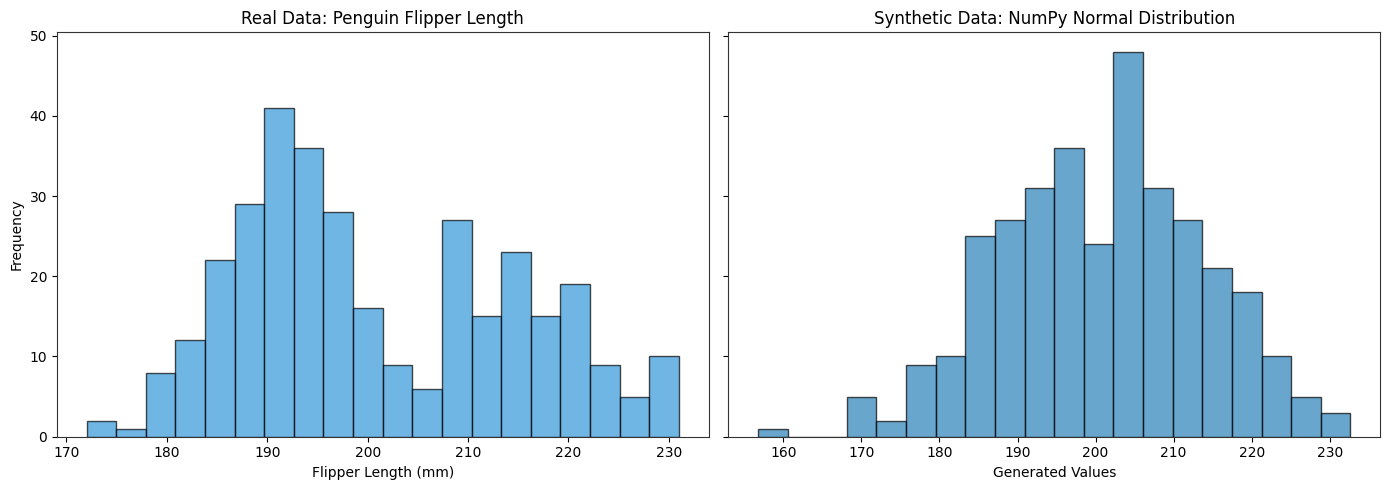

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Plot real-world biological normal distribution
axes[0].hist(real_normal, bins=20, color='#3498db', edgecolor='black', alpha=0.7)
axes[0].set_title('Real Data: Penguin Flipper Length')
axes[0].set_xlabel('Flipper Length (mm)')
axes[0].set_ylabel('Frequency')

# Plot synthetic mathematical normal distribution
axes[1].hist(synthetic_normal, bins=20, color='#2980b9', edgecolor='black', alpha=0.7)
axes[1].set_title('Synthetic Data: NumPy Normal Distribution')
axes[1].set_xlabel('Generated Values')

plt.tight_layout()
plt.show()

## **3. Model the Uniform Distribution**
A Uniform distribution is a continuous distribution where all outcomes within a specified boundary are equally likely to occur $\implies$ results in a flat probability density function.

* **Synthetic Data Generation:** We use `np.random.uniform()` to create a flat distribution between 0 and 100.
* **Real-World Proxy Comparison:** While natural measurements rarely form perfect flat rectangles, we mock an ideal uniform baseline by using the sequence index of the data records.

In [9]:
# Create a real-world linear baseline utilizing dataframe indexes
real_uniform = np.arange(len(penguins_df))

# Set distribution constraints matching the scale of our records
low_bound, high_bound = 0, len(penguins_df)

# Generate synthetic uniform samples where every value has equal probability
synthetic_uniform = np.random.uniform(low=low_bound, high=high_bound, size=len(penguins_df))

# Print verification metrics and display raw instances of the synthetic uniform array
print("Uniform distribution data metrics:")
print(f"Defined Bounds: Low = {low_bound}, High = {high_bound}")
print(f"Generated Synthetic Array Shape: {synthetic_uniform.shape}")
print(f"Theoretical Mean: {(low_bound + high_bound) / 2:.2f}")
print(f"Synthetic Data Empirical Mean: {np.mean(synthetic_uniform):.2f}")
print("\nFirst 15 instances of generated Synthetic Uniform Data (Continuous uniform floats):")
print(synthetic_uniform[:15])

Uniform distribution data metrics:
Defined Bounds: Low = 0, High = 333
Generated Synthetic Array Shape: (333,)
Theoretical Mean: 166.50
Synthetic Data Empirical Mean: 173.52

First 15 instances of generated Synthetic Uniform Data (Continuous uniform floats):
[ 94.43572814  73.16836641 134.39175634  11.56081184   8.80671099
 277.86590536 244.54363655 211.61484343 161.55431708  70.15973503
 158.61300678 222.36757491 137.13660373 192.44469213 150.66216576]


### **Visualize the Uniform Distribution**
The histograms below demonstrate the contrast between a structured, ordered sequence and purely random, uniformly distributed synthetic float data.

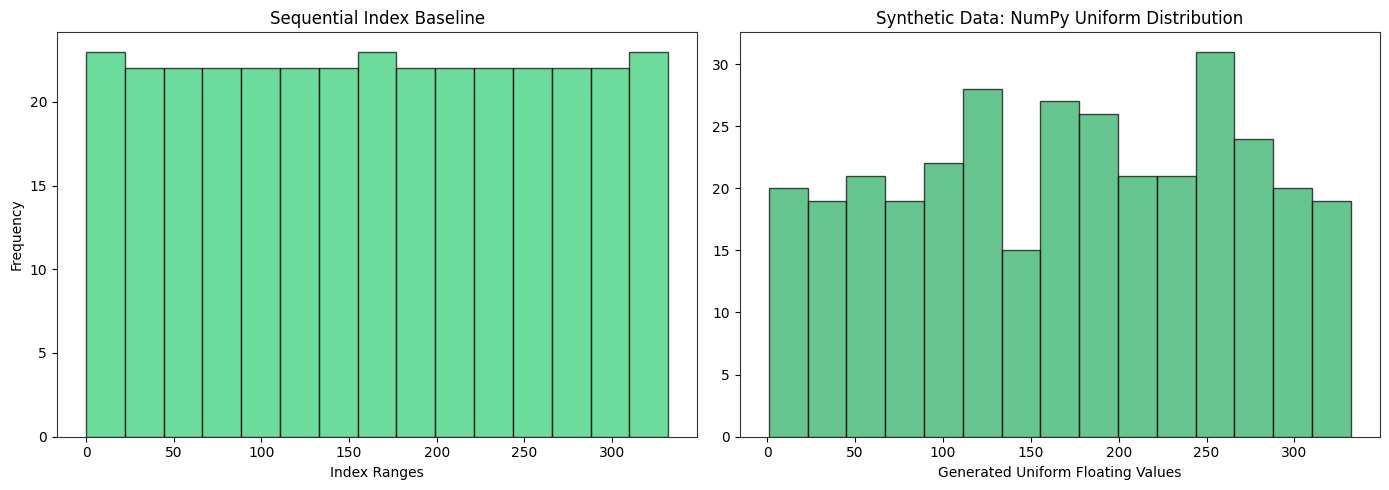

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot structural sequential sample data
axes[0].hist(real_uniform, bins=15, color='#2ecc71', edgecolor='black', alpha=0.7)
axes[0].set_title('Sequential Index Baseline')
axes[0].set_xlabel('Index Ranges')
axes[0].set_ylabel('Frequency')

# Plot synthetic uniform data demonstrating flat behavior
axes[1].hist(synthetic_uniform, bins=15, color='#27ae60', edgecolor='black', alpha=0.7)
axes[1].set_title('Synthetic Data: NumPy Uniform Distribution')
axes[1].set_xlabel('Generated Uniform Floating Values')

plt.tight_layout()
plt.show()

## **4. Model the Binomial Distribution**
The Binomial distribution is a discrete distribution that models the number of successful outcomes across a sequence of independent Bernoulli trials (success/failure experiments).

* **Synthetic Data Generation:** We use `np.random.binomial(n, p)` where `n` is the number of trials and `p` is the probability of success.
* **Real-World Comparison:** We convert the categorical `sex` attribute into a binary metric (1 for Male, 0 for Female) to analyze the frequency of binomial occurrences.

In [11]:
# Convert categorical sex data to a binary variable representation (Male = 1, Female = 0)
binary_sex = (penguins_df['sex'] == 'Male').astype(int).values

# Compute the empirical probability of a penguin being Male
prob_male = np.mean(binary_sex)

# Define experimental trials: simulating groups of 10 independent trials
trials = 10

# Generate synthetic discrete binomial outcomes based on computed probability
synthetic_binomial = np.random.binomial(n=trials, p=prob_male, size=len(binary_sex))

# Print verification metrics and display raw discrete instances of the synthetic array
print("Binomial distribution data metrics:\n")
print(f"Calculated Success Probability (P of Male in dataset): {prob_male:.4f}")
print(f"Number of trials per experiment (n): {trials}")
print(f"Generated Synthetic Array Shape: {synthetic_binomial.shape}")
print(f"Expected theoretical mean outcome (n * p): {trials * prob_male:.2f}")
print(f"Synthetic Data Empirical Mean outcome: {np.mean(synthetic_binomial):.2f}")
print("\nFirst 20 instances of generated Synthetic Binomial Data (Number of successes out of 10 trials):")
print(synthetic_binomial[:20])

Binomial distribution data metrics:

Calculated Success Probability (P of Male in dataset): 0.5045
Number of trials per experiment (n): 10
Generated Synthetic Array Shape: (333,)
Expected theoretical mean outcome (n * p): 5.05
Synthetic Data Empirical Mean outcome: 5.05

First 20 instances of generated Synthetic Binomial Data (Number of successes out of 10 trials):
[3 4 8 4 4 6 3 7 4 2 1 6 5 5 5 6 6 6 8 5]


### Visualizing the Binomial Distribution
Because the binomial distribution tracks distinct integers (success counts), we use narrower step intervals to properly map out the discrete frequencies.

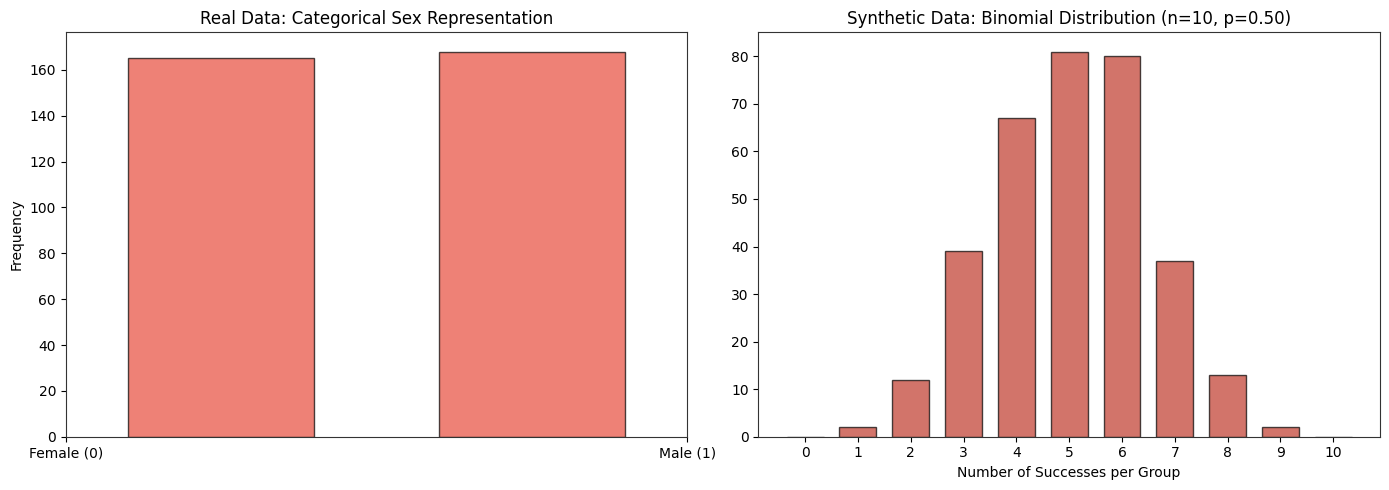

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot binary categorical data split (Single Bernoulli Trial outcome)
axes[0].hist(binary_sex, bins=2, color='#e74c3c', edgecolor='black', alpha=0.7, rwidth=0.6)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Female (0)', 'Male (1)'])
axes[0].set_title('Real Data: Categorical Sex Representation')
axes[0].set_ylabel('Frequency')

# Plot simulated multi-trial binomial distribution results
axes[1].hist(synthetic_binomial, bins=np.arange(trials + 2) - 0.5, color='#c0392b', edgecolor='black', alpha=0.7, rwidth=0.7)
axes[1].set_xticks(range(trials + 1))
axes[1].set_title(f'Synthetic Data: Binomial Distribution (n={trials}, p={prob_male:.2f})')
axes[1].set_xlabel('Number of Successes per Group')

plt.tight_layout()
plt.show()

## **5. Comparative Analysis and Conclusion**

### **Distribution Summary Matrix**

| Distribution Type | Data Nature | Shape Characterization | Practical Real-World Analogy |
| :--- | :--- | :--- | :--- |
| **Normal** | Continuous | Symmetric Bell Curve centered on Mean | Biological metrics (Weight, Flipper Length) |
| **Uniform** | Continuous | Flat rectangular baseline | Random number generators, unbiased sampling |
| **Binomial** | Discrete | Disjoint vertical bars mapping integers | Operational failure rates, Head/Tail flipping sequences |

### **Lab Conclusion**
Through this experiment, we successfully navigated synthetic data generation protocols using NumPy algorithms and cross-referenced them with actual ecological profiles.

Mapping analytical configurations via Matplotlib histograms confirmed that synthetic generation models accurately replicate mathematical behavior found in physical environments. So, they provide a crucial tool for constructing robust AI modeling environments before relying on sparse real-world records.